In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
loan = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\Loans.csv")

customer = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\Customers.csv")

repayment = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\Repayments.csv")

transaction = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\Transactions.csv")

branch = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\Branches.csv")

fraud = pd.read_csv(r"C:\Users\Bharath Venkatesh\Downloads\Whitefield Bank\raw\FraudCases.csv")

In [3]:
loan.head()

,LoanID,ApplicationID,CustomerID,BranchID,ProductID,LoanType,SanctionDate,DisbursementDate,SanctionedAmount,InterestRate,TenureMonths,EMI,OutstandingPrincipal,LoanStatus
0,LN0000001,APP0000001,WB00083811,BR0325,P001,Home Loan,22-02-2026,22-02-2026,5461834,8.42,283,44471.49,5352597.32,Active
1,LN0000002,APP0000003,WB00093851,BR0020,P006,SME Loan,25-01-2023,25-01-2023,38102967,13.42,41,1163722.34,0.00,Closed
2,LN0000003,APP0000004,WB00044598,BR0079,P003,Vehicle Loan,28-06-2021,28-06-2021,1533050,10.57,29,60133.96,30661.00,Active
3,LN0000004,APP0000005,WB00005696,BR0499,P006,SME Loan,20-11-2023,20-11-2023,32064247,12.03,53,782831.48,17202372.33,Active
4,LN0000005,APP0000006,WB00092350,BR0450,P001,Home Loan,13-02-2022,13-02-2022,27113686,9.30,286,236082.48,22805086.39,Active


In [ ]:
customer.head()

,CustomerID,FirstName,LastName,Gender,DateOfBirth,Age,PAN,Aadhaar,Mobile,Email,...,CreditScore,MaritalStatus,City,State,Pincode,CustomerSince,KYCStatus,PreferredChannel,BranchID,IsActive
0,WB00000001,Amit,Patel,Male,1994-12-04,32,RXCKA4582H,501652580863,9193008687,amit.patel1@mail.com,...,550,Single,Bengaluru,Karnataka,560001,2022-02-18,Verified,Internet Banking,BR0023,1
1,WB00000002,Pooja,Patel,Male,2003-02-13,23,HQJJF5374W,966171396568,9720322983,pooja.patel2@mail.com,...,596,Married,Chennai,Tamil Nadu,600001,2024-03-09,Verified,Internet Banking,BR0134,1
2,WB00000003,Vivek,Joshi,Female,1976-02-25,50,BCQUK2040M,395980765261,9449825198,vivek.joshi3@mail.com,...,441,Single,Bengaluru,Karnataka,560001,2014-06-25,Verified,Branch,BR0045,1
3,WB00000004,Neha,Sharma,Male,1993-04-19,33,YCMBT3060E,691569976736,9384200550,neha.sharma4@mail.com,...,614,Single,Mumbai,Maharashtra,400001,2012-01-28,Verified,Mobile App,BR0078,1
4,WB00000005,Neha,Nair,Male,1978-08-26,48,KCRJK1887V,660781151148,9088065007,neha.nair5@mail.com,...,890,Single,Hyderabad,Telangana,500001,2023-08-16,Verified,UPI,BR0167,1


In [5]:
repayment.head()

,RepaymentID,LoanID,CustomerID,EMINumber,DueDate,PaymentDate,EMIAmount,PrincipalPaid,InterestPaid,OutstandingBalance,PaymentStatus,DaysPastDue,PaymentMode,CollectionRequired
0,RP000000001,LN0000001,WB00083811,1,2026-03-22,2026-03-22,44471.49,6147.62,38323.87,5455686.38,Paid,0,Auto Debit,No
1,RP000000002,LN0000001,WB00083811,2,2026-04-22,2026-04-22,44471.49,6190.76,38280.73,5449495.62,Paid,0,Auto Debit,No
2,RP000000003,LN0000001,WB00083811,3,2026-05-22,2026-05-22,44471.49,6234.20,38237.29,5443261.43,Paid,0,Auto Debit,No
3,RP000000004,LN0000001,WB00083811,4,2026-06-22,2026-06-22,44471.49,6277.94,38193.55,5436983.49,Paid,0,NEFT,No
4,RP000000005,LN0000001,WB00083811,5,2026-07-22,2026-07-22,44471.49,6321.99,38149.50,5430661.50,Paid,0,Auto Debit,No


In [6]:
transaction.head()

,TransactionID,CustomerID,BranchID,TransactionDateTime,TransactionType,DebitCredit,Amount,Channel,Merchant,City,State,FraudFlag
0,TXN000000001,WB00083811,BR0325,2025-07-29 23:30:11,UPI,Debit,7334,UPI,Flipkart,Mysuru,Karnataka,0
1,TXN000000002,WB00071483,BR0005,2024-11-23 17:11:34,UPI,Debit,3090,UPI,IRCTC,Bengaluru,Karnataka,0
2,TXN000000003,WB00073564,BR0473,2025-05-19 18:43:26,UPI,Debit,13766,UPI,Apollo Pharmacy,New Delhi,Delhi,0
3,TXN000000004,WB00000852,BR0110,2024-05-04 00:15:55,NEFT,Debit,366778,UPI,DMart,New Delhi,Delhi,0
4,TXN000000005,WB00044119,BR0467,2024-10-22 02:21:29,UPI,Debit,11290,ATM,Amazon,Bengaluru,Karnataka,0


In [7]:
branch.head()

,BranchID,BranchCode,BranchName,IFSCCode,BranchType,Region,State,City,Pincode,Address,OpeningDate,ManagerID,Latitude,Longitude,IsActive
0,BR0001,WB001,Bengaluru Branch 1,WFBK000001,Urban,South,Karnataka,Bengaluru,560001,"100, Bengaluru",2005-12-09,NaN,12.9716,77.5946,1
1,BR0002,WB002,Bengaluru Branch 2,WFBK000002,Retail,South,Karnataka,Bengaluru,560001,"101, Bengaluru",2008-11-24,NaN,12.9716,77.5946,1
2,BR0003,WB003,Bengaluru Branch 3,WFBK000003,Retail,South,Karnataka,Bengaluru,560001,"102, Bengaluru",2018-01-01,NaN,12.9716,77.5946,1
3,BR0004,WB004,Bengaluru Branch 4,WFBK000004,Retail,South,Karnataka,Bengaluru,560001,"103, Bengaluru",2024-01-18,NaN,12.9716,77.5946,1
4,BR0005,WB005,Bengaluru Branch 5,WFBK000005,Urban,South,Karnataka,Bengaluru,560001,"104, Bengaluru",2022-07-08,NaN,12.9716,77.5946,1


In [8]:
fraud.head()

,FraudCaseID,TransactionID,CustomerID,BranchID,FraudType,TransactionAmount,TransactionDate,DetectionDate,InvestigationDays,FraudStatus,RecoveredAmount,FinancialLoss,FraudChannel,Merchant
0,FRD00002111,TXN000002111,WB00013969,BR0467,Card Skimming,4506,2024-08-21 04:13:44,2024-08-23 04:13:44,19,Open,0.00,4506.00,ATM,Zomato
1,FRD00002428,TXN000002428,WB00017811,BR0401,Card Skimming,1558,2025-03-26 18:46:01,2025-03-31 18:46:01,59,Closed,679.74,878.26,UPI,Zomato
2,FRD00002860,TXN000002860,WB00033278,BR0174,Fake Merchant,9173,2025-12-17 04:14:42,2025-12-22 04:14:42,7,Open,0.00,9173.00,Internet Banking,Flipkart
3,FRD00003371,TXN000003371,WB00073640,BR0105,UPI Fraud,32213,2024-11-20 01:42:51,2024-11-25 01:42:51,47,Closed,16747.78,15465.22,Mobile App,IRCTC
4,FRD00004382,TXN000004382,WB00048657,BR0138,Fake Merchant,80688,2024-06-21 23:03:59,2024-06-22 23:03:59,39,Investigating,4489.33,76198.67,POS,Amazon


In [10]:
loan.shape

(147579, 14)

In [11]:
customer.shape

(100000, 23)

In [12]:
repayment.shape

(1756874, 14)

In [13]:
transaction.shape

(100000, 12)

In [14]:
branch.shape

(500, 15)

In [15]:
fraud.shape

(196, 14)

In [17]:
loan.describe(include='object')

,LoanID,ApplicationID,CustomerID,BranchID,ProductID,LoanType,SanctionDate,DisbursementDate,LoanStatus
count,147579,147579,147579,147579,147579,147579,147579,147579,147579
unique,147579,147579,72985,500,7,7,2016,2016,4
top,LN0000001,APP0000001,WB00041456,BR0406,P001,Home Loan,12-12-2021,12-12-2021,Active
freq,1,1,12,390,21250,21250,103,103,121219


In [18]:
customer.describe(include='object')

,CustomerID,FirstName,LastName,Gender,DateOfBirth,PAN,Email,Occupation,EmploymentType,MaritalStatus,City,State,CustomerSince,KYCStatus,PreferredChannel,BranchID
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,15,12,2,20986,100000,100000,20,5,2,10,8,5712,2,4,500
top,WB00000001,Rahul,Mehta,Male,1970-03-09,RXCKA4582H,amit.patel1@mail.com,Electrician,Salaried,Single,New Delhi,Maharashtra,2019-01-02,Verified,UPI,BR0055
freq,1,6774,8410,50349,15,1,1,5102,59825,50110,13344,21101,34,95026,25172,252


In [24]:
repayment.describe(include='object')

,RepaymentID,LoanID,CustomerID,DueDate,PaymentDate,PaymentStatus,PaymentMode,CollectionRequired
count,1756874,1756874,1756874,1756874,1631006,1756874,1756874,1756874
unique,1756874,147579,72985,2324,2549,3,5,2
top,RP000000001,LN0000001,WB00041456,2025-02-12,2025-03-12,Paid,Auto Debit,No
freq,1,12,144,992,914,1491412,966601,1631006


In [20]:
transaction.describe(include='object')

,TransactionID,CustomerID,BranchID,TransactionDateTime,TransactionType,DebitCredit,Channel,Merchant,City,State
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,63218,500,99933,8,2,6,10,10,8
top,TXN000000001,WB00084321,BR0440,2024-01-12 19:02:21,UPI,Debit,UPI,IRCTC,New Delhi,Maharashtra
freq,1,7,257,2,40323,75389,29984,10123,13442,20983


In [21]:
branch.describe(include='object')

,BranchID,BranchCode,BranchName,IFSCCode,BranchType,Region,State,City,Address,OpeningDate
count,500,500,500,500,500,500,500,500,500,500
unique,500,500,500,500,5,4,8,10,500,484
top,BR0001,WB001,Bengaluru Branch 1,WFBK000001,Retail,South,Maharashtra,New Delhi,"100, Bengaluru",2011-06-04
freq,1,1,1,1,296,241,104,67,1,2


In [22]:
fraud.describe(include='object')

,FraudCaseID,TransactionID,CustomerID,BranchID,FraudType,TransactionDate,DetectionDate,FraudStatus,FraudChannel,Merchant
count,196,196,196,196,196,196,196,196,196,196
unique,196,196,196,151,9,196,196,5,6,10
top,FRD00002111,TXN000002111,WB00013969,BR0269,Internet Banking Fraud,2024-08-21 04:13:44,2024-08-23 04:13:44,Closed,UPI,IRCTC
freq,1,1,1,3,29,1,1,53,62,28


In [25]:
loan.isnull().sum()

LoanID                  0
ApplicationID           0
CustomerID              0
BranchID                0
ProductID               0
LoanType                0
SanctionDate            0
DisbursementDate        0
SanctionedAmount        0
InterestRate            0
TenureMonths            0
EMI                     0
OutstandingPrincipal    0
LoanStatus              0
dtype: int64

In [26]:
customer.isnull().sum()

CustomerID          0
FirstName           0
LastName            0
Gender              0
DateOfBirth         0
Age                 0
PAN                 0
Aadhaar             0
Mobile              0
Email               0
Occupation          0
EmploymentType      0
AnnualIncome        0
CreditScore         0
MaritalStatus       0
City                0
State               0
Pincode             0
CustomerSince       0
KYCStatus           0
PreferredChannel    0
BranchID            0
IsActive            0
dtype: int64

In [27]:
repayment.isnull().sum()

RepaymentID                0
LoanID                     0
CustomerID                 0
EMINumber                  0
DueDate                    0
PaymentDate           125868
EMIAmount                  0
PrincipalPaid              0
InterestPaid               0
OutstandingBalance         0
PaymentStatus              0
DaysPastDue                0
PaymentMode                0
CollectionRequired         0
dtype: int64

In [34]:
missing = repayment.isnull().sum()/len(repayment)*100

missing.sort_values(ascending=False)

PaymentDate           7.164316
RepaymentID           0.000000
LoanID                0.000000
CustomerID            0.000000
EMINumber             0.000000
DueDate               0.000000
EMIAmount             0.000000
PrincipalPaid         0.000000
InterestPaid          0.000000
OutstandingBalance    0.000000
PaymentStatus         0.000000
DaysPastDue           0.000000
PaymentMode           0.000000
CollectionRequired    0.000000
dtype: float64

In [28]:
transaction.isnull().sum()

TransactionID          0
CustomerID             0
BranchID               0
TransactionDateTime    0
TransactionType        0
DebitCredit            0
Amount                 0
Channel                0
Merchant               0
City                   0
State                  0
FraudFlag              0
dtype: int64

In [29]:
branch.isnull().sum()

BranchID         0
BranchCode       0
BranchName       0
IFSCCode         0
BranchType       0
Region           0
State            0
City             0
Pincode          0
Address          0
OpeningDate      0
ManagerID      500
Latitude         0
Longitude        0
IsActive         0
dtype: int64

In [33]:
missing = branch.isnull().sum()/len(branch)*100

missing.sort_values(ascending=False)

ManagerID      100.0
BranchCode       0.0
BranchID         0.0
IFSCCode         0.0
BranchType       0.0
Region           0.0
BranchName       0.0
State            0.0
City             0.0
Address          0.0
Pincode          0.0
OpeningDate      0.0
Latitude         0.0
Longitude        0.0
IsActive         0.0
dtype: float64

In [30]:
fraud.isnull().sum()

FraudCaseID          0
TransactionID        0
CustomerID           0
BranchID             0
FraudType            0
TransactionAmount    0
TransactionDate      0
DetectionDate        0
InvestigationDays    0
FraudStatus          0
RecoveredAmount      0
FinancialLoss        0
FraudChannel         0
Merchant             0
dtype: int64

In [37]:
loan.duplicated().sum()

np.int64(0)

In [38]:
customer.duplicated().sum()

np.int64(0)

In [39]:
repayment.duplicated().sum()

np.int64(0)

In [40]:
transaction.duplicated().sum()

np.int64(0)

In [41]:
branch.duplicated().sum()

np.int64(0)

In [42]:
fraud.duplicated().sum()

np.int64(0)

In [43]:
loan['SanctionDate']=pd.to_datetime(loan['SanctionDate'])

In [44]:
loan['DisbursementDate']=pd.to_datetime(loan['DisbursementDate'])

In [45]:
customer['CustomerSince']=pd.to_datetime(customer['CustomerSince'])

In [46]:
transaction['TransactionDateTime']=pd.to_datetime(transaction['TransactionDateTime'])

In [47]:
fraud['TransactionDate']=pd.to_datetime(fraud['TransactionDate'])

In [48]:
repayment['PaymentDate']=pd.to_datetime(repayment['PaymentDate'])

In [49]:
loan['LoanStatus'].value_counts()

LoanStatus
Active         121219
Closed          17566
Defaulted        7299
Written Off      1495
Name: count, dtype: int64

<Axes: xlabel='LoanType'>

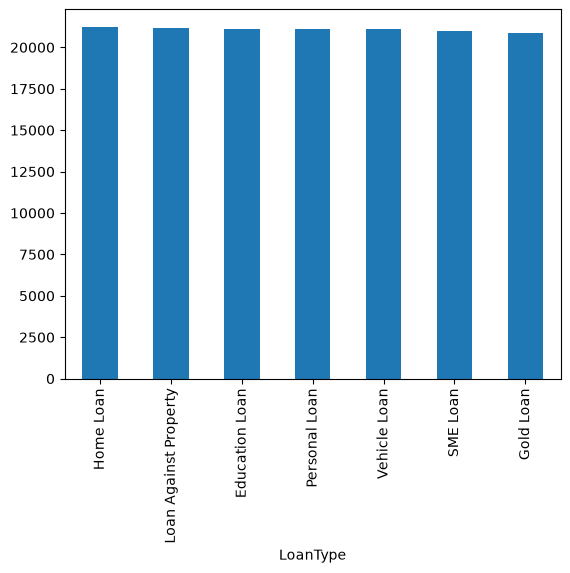

In [50]:
loan['LoanType'].value_counts().plot(kind='bar')

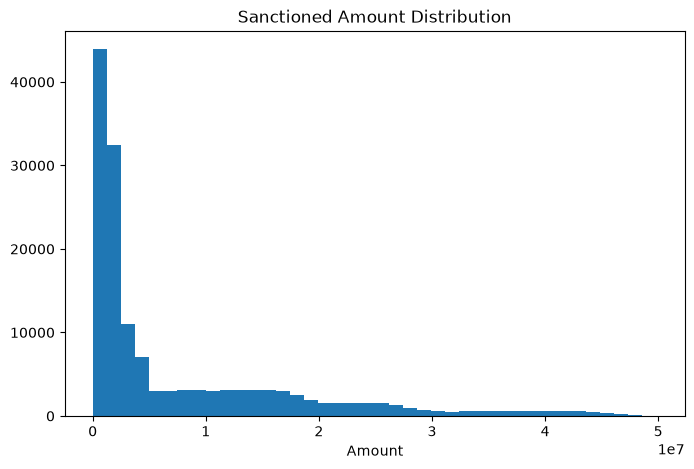

In [52]:
plt.figure(figsize=(8,5))

plt.hist(
loan['SanctionedAmount'],
bins=40
)

plt.title("Sanctioned Amount Distribution")
plt.xlabel("Amount")
plt.show()

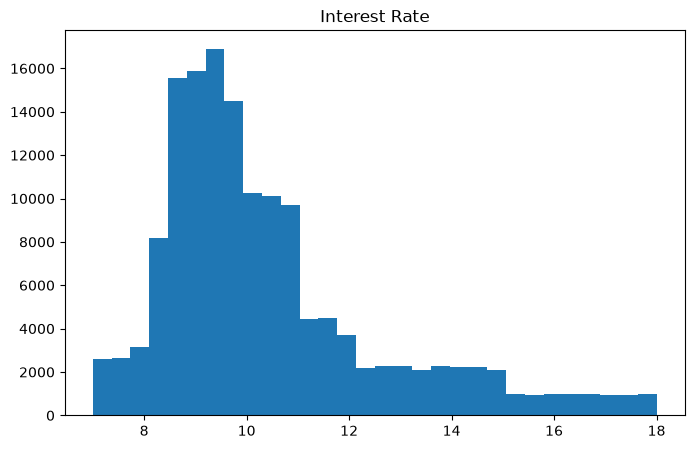

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
loan['InterestRate'],
bins=30
)

plt.title("Interest Rate")
plt.show()

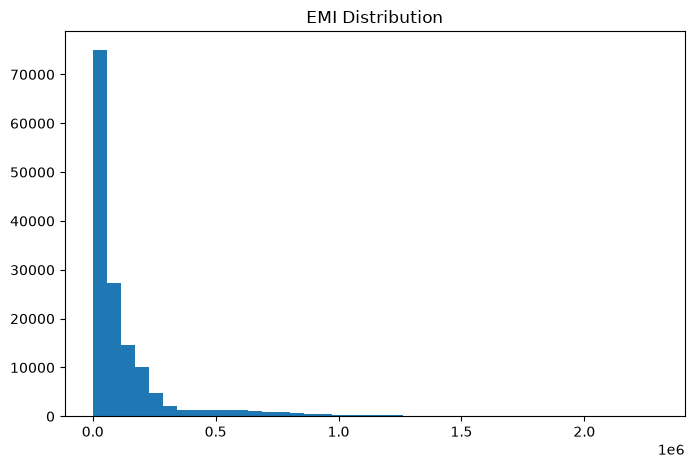

In [54]:
plt.figure(figsize=(8,5))

plt.hist(
loan['EMI'],
bins=40
)

plt.title("EMI Distribution")
plt.show()

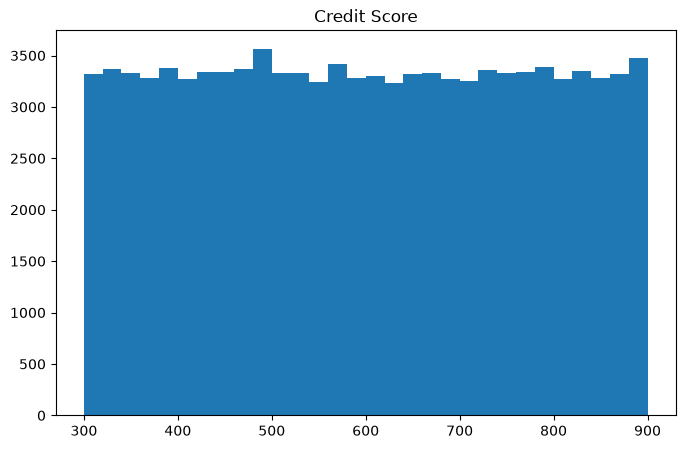

In [55]:
plt.figure(figsize=(8,5))

plt.hist(
customer['CreditScore'],
bins=30
)

plt.title("Credit Score")
plt.show()

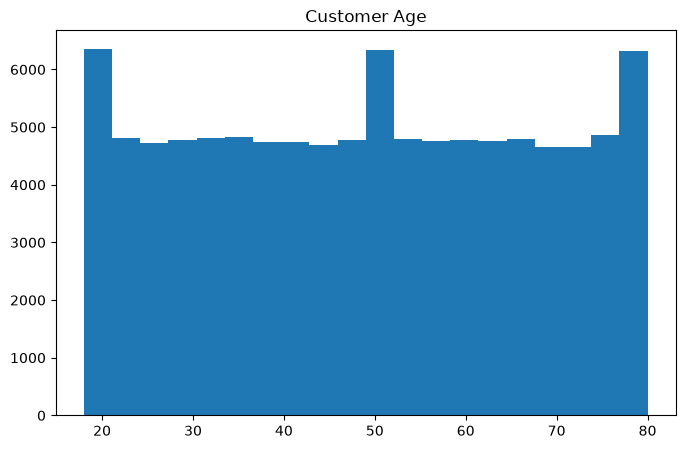

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
customer['Age'],
bins=20
)

plt.title("Customer Age")
plt.show()

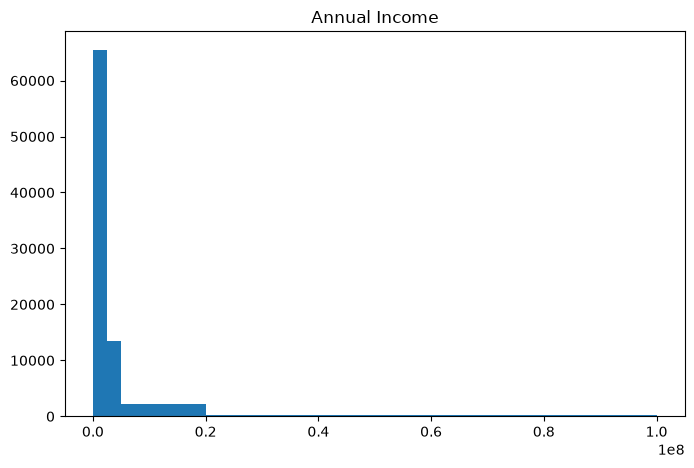

In [57]:
plt.figure(figsize=(8,5))

plt.hist(
customer['AnnualIncome'],
bins=40
)

plt.title("Annual Income")
plt.show()

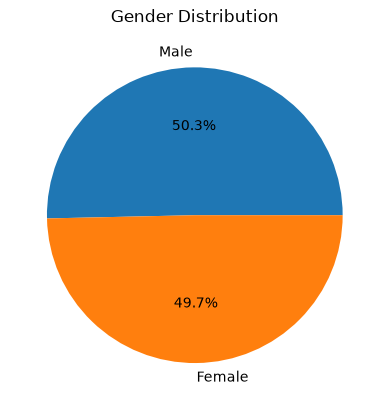

In [58]:
customer['Gender'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

In [59]:
customer['State'].value_counts().head(10)

State
Maharashtra    21101
Karnataka      19832
Delhi          13344
Telangana      10554
Tamil Nadu     10271
West Bengal     8694
Gujarat         8548
Kerala          7656
Name: count, dtype: int64

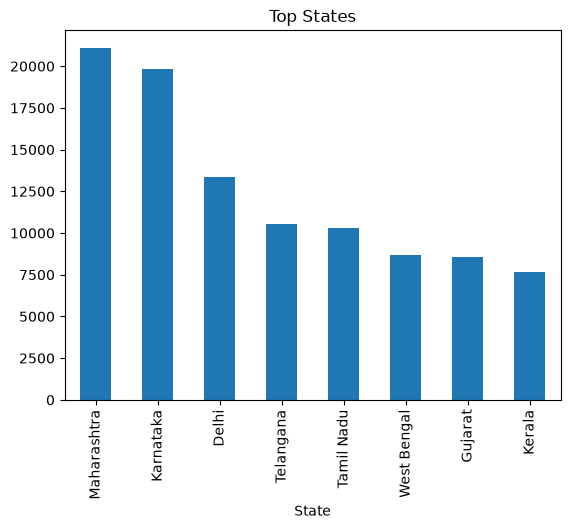

In [60]:
customer['State'].value_counts().head(10).plot(
kind='bar'
)

plt.title("Top States")
plt.show()

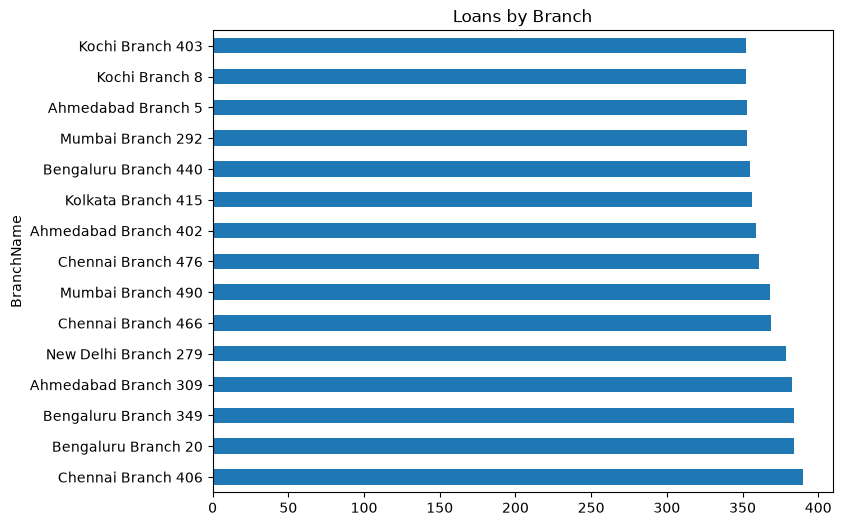

In [61]:
branch_loan=loan.merge(
branch[['BranchID','BranchName']],
on='BranchID'
)

branch_loan.groupby('BranchName')['LoanID']\
.count()\
.sort_values(ascending=False)\
.head(15)\
.plot(kind='barh',figsize=(8,6))

plt.title("Loans by Branch")
plt.show()

In [62]:
portfolio=branch_loan.groupby(
'BranchName'
)['SanctionedAmount'].sum().sort_values(ascending=False)

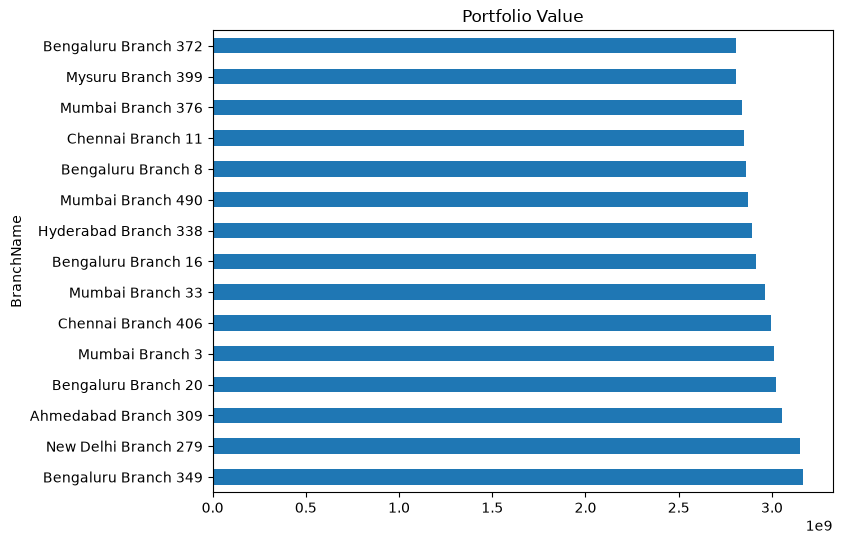

In [63]:
portfolio.head(15).plot(
kind='barh',
figsize=(8,6)
)

plt.title("Portfolio Value")
plt.show()

In [64]:
pd.crosstab(
loan['LoanType'],
loan['LoanStatus']
)

LoanStatus,Active,Closed,Defaulted,Written Off
LoanType,,,,
Education Loan,17298,2560,1068,207
Gold Loan,17086,2510,1034,222
Home Loan,17486,2511,1057,196
Loan Against Property,17437,2480,1026,204
Personal Loan,17371,2464,1062,234
SME Loan,17186,2551,1016,218
Vehicle Loan,17355,2490,1036,214


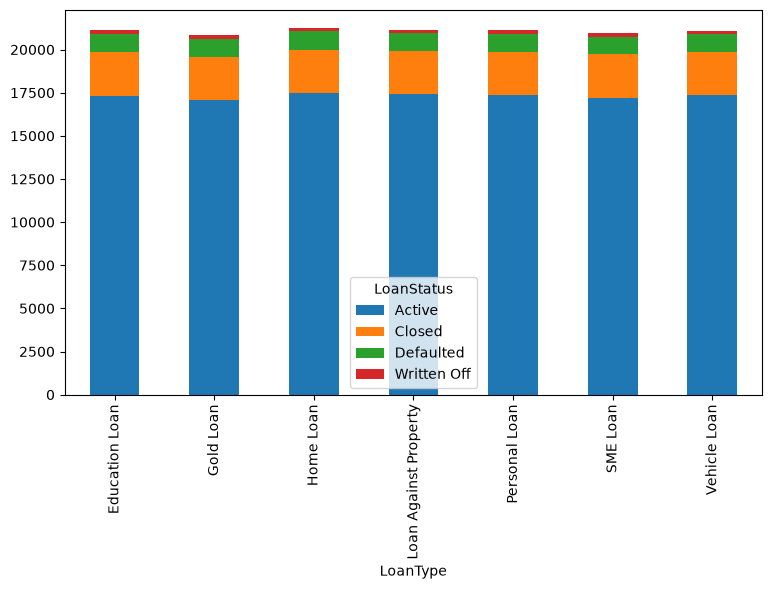

In [65]:
pd.crosstab(
loan['LoanType'],
loan['LoanStatus']
).plot(
kind='bar',
stacked=True,
figsize=(9,5)
)

plt.show()

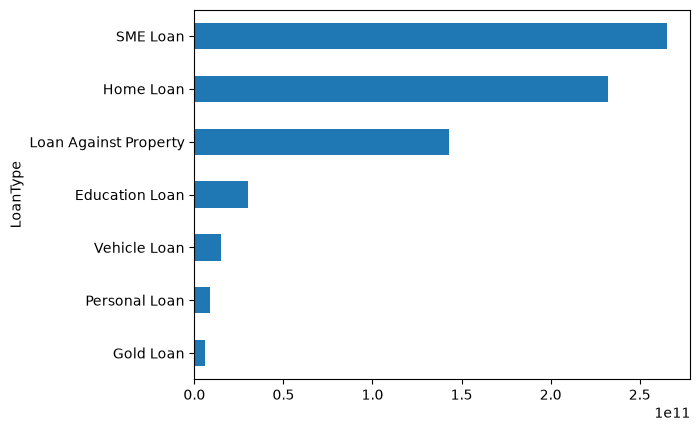

In [66]:
loan.groupby(
'LoanType'
)['OutstandingPrincipal']\
.sum()\
.sort_values()\
.plot(kind='barh')

plt.show()

In [67]:
repayment['PaymentStatus'].value_counts()

PaymentStatus
Paid      1491412
Late       139594
Missed     125868
Name: count, dtype: int64

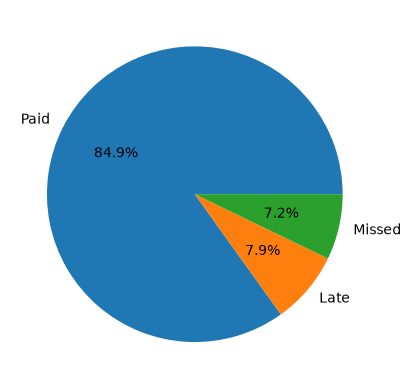

In [68]:
repayment['PaymentStatus'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

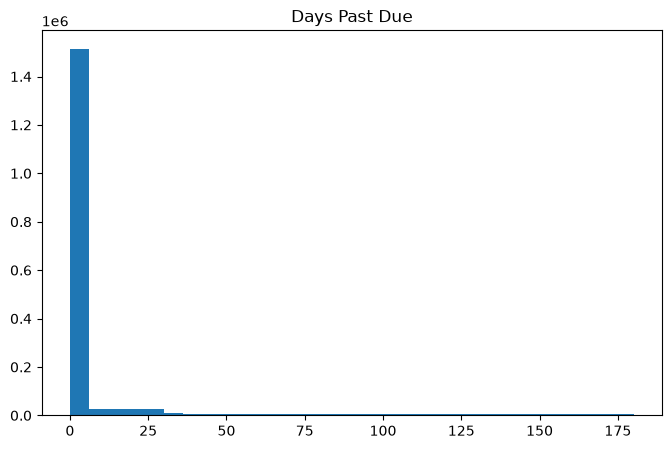

In [69]:
plt.figure(figsize=(8,5))

plt.hist(
repayment['DaysPastDue'],
bins=30
)

plt.title("Days Past Due")
plt.show()

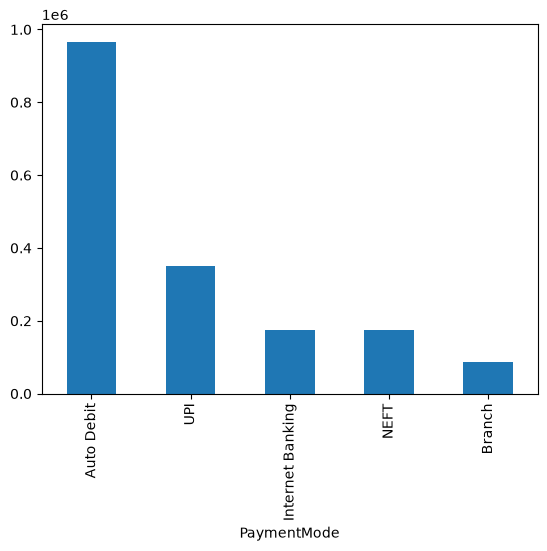

In [70]:
repayment['PaymentMode'].value_counts().plot(
kind='bar'
)

plt.show()

In [71]:
repayment['CollectionRequired'].value_counts()

CollectionRequired
No     1631006
Yes     125868
Name: count, dtype: int64

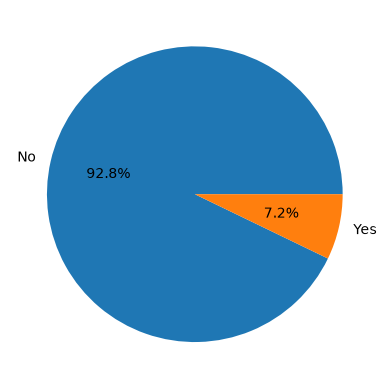

In [72]:
repayment['CollectionRequired'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

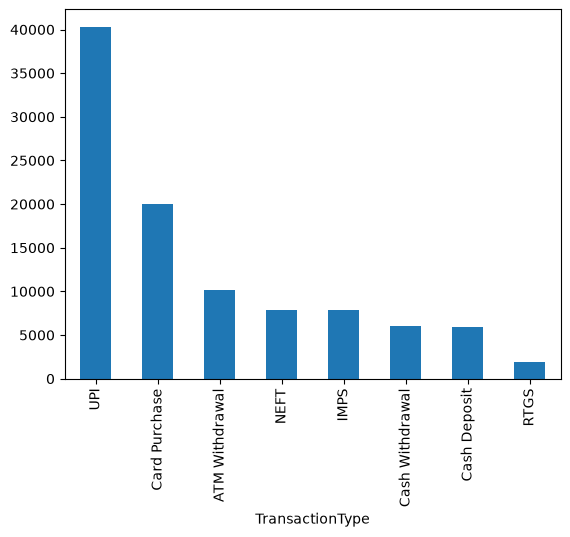

In [73]:
transaction['TransactionType'].value_counts().plot(
kind='bar'
)

plt.show()

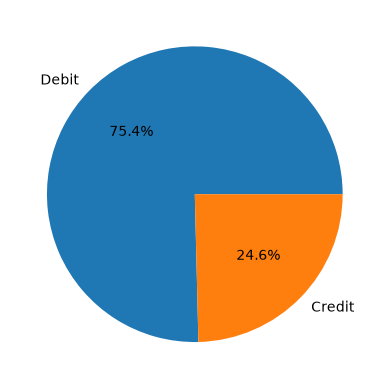

In [74]:
transaction['DebitCredit'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

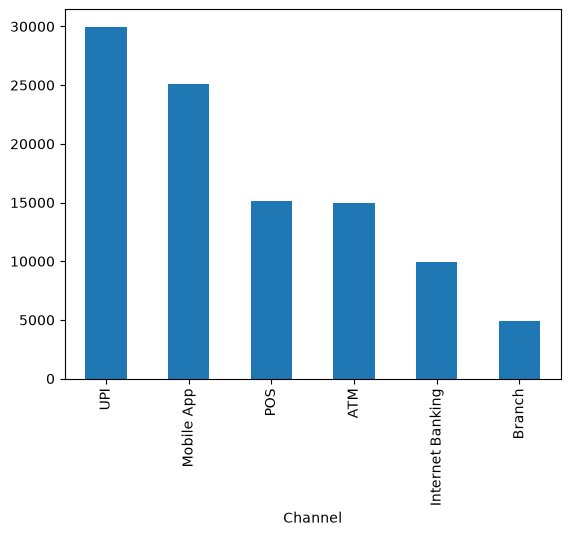

In [75]:
transaction['Channel'].value_counts().plot(
kind='bar'
)

plt.show()

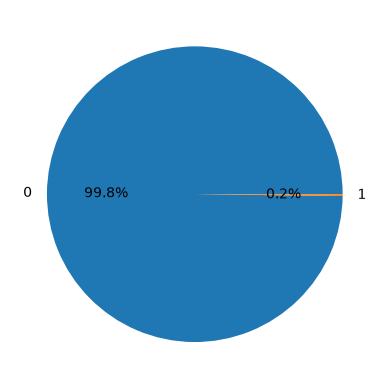

In [76]:
transaction['FraudFlag'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

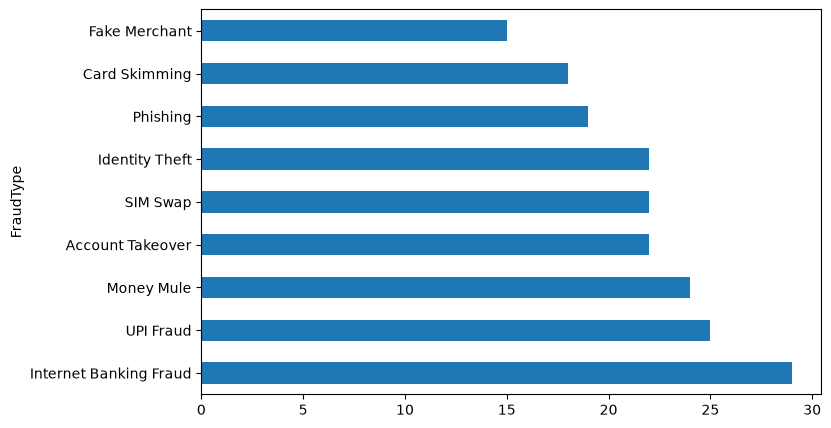

In [77]:
fraud['FraudType'].value_counts().plot(
kind='barh',
figsize=(8,5)
)

plt.show()

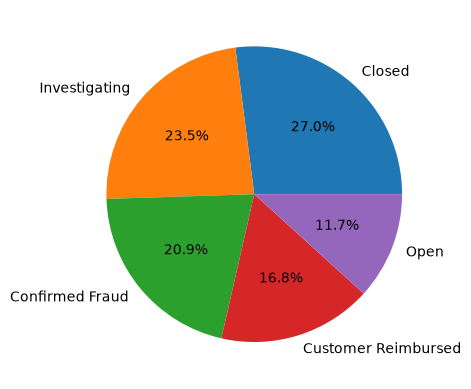

In [78]:
fraud['FraudStatus'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

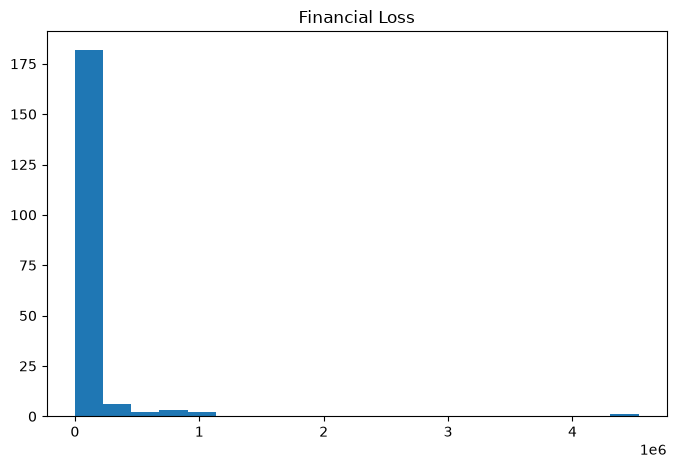

In [79]:
plt.figure(figsize=(8,5))

plt.hist(
fraud['FinancialLoss'],
bins=20
)

plt.title("Financial Loss")
plt.show()

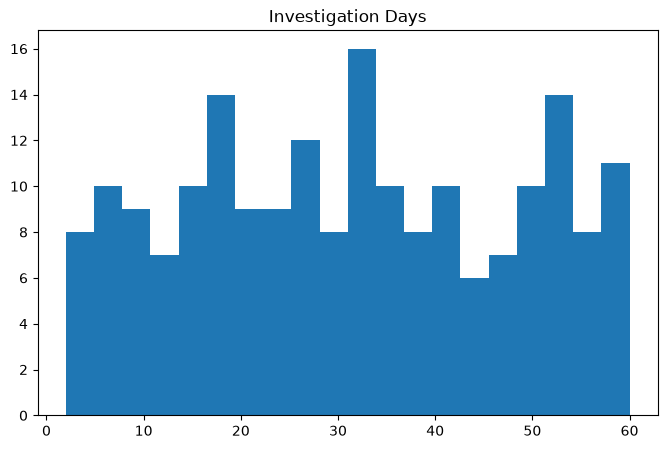

In [80]:
plt.figure(figsize=(8,5))

plt.hist(
fraud['InvestigationDays'],
bins=20
)

plt.title("Investigation Days")
plt.show()

In [81]:
loan_corr=loan.select_dtypes(include=np.number)

loan_corr.corr()

,SanctionedAmount,InterestRate,TenureMonths,EMI,OutstandingPrincipal
SanctionedAmount,1.000000,0.053064,0.306639,0.853902,0.808694
InterestRate,0.053064,1.000000,-0.247594,0.160816,-0.011735
TenureMonths,0.306639,-0.247594,1.000000,-0.039982,0.390888
EMI,0.853902,0.160816,-0.039982,1.000000,0.574676
OutstandingPrincipal,0.808694,-0.011735,0.390888,0.574676,1.000000


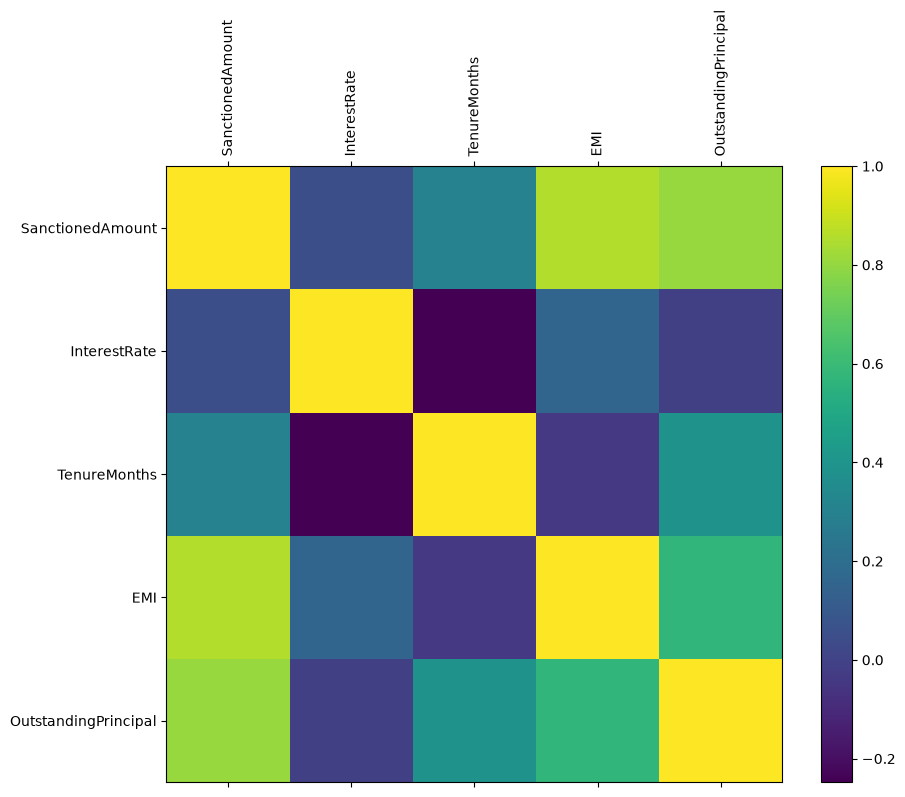

In [82]:
import matplotlib.pyplot as plt

corr=loan_corr.corr()

fig,ax=plt.subplots(figsize=(10,8))

cax=ax.matshow(corr)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)

fig.colorbar(cax)

plt.show()

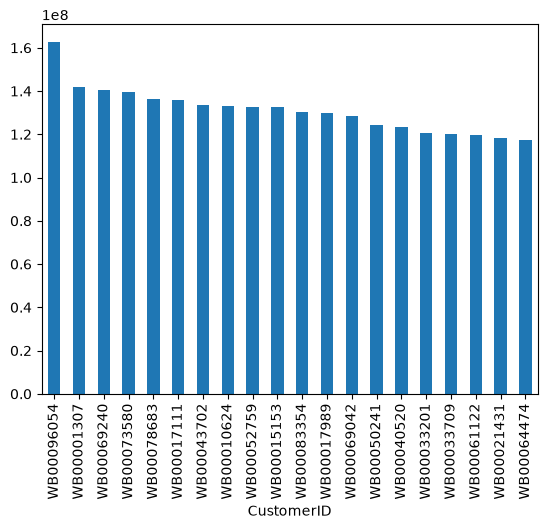

In [83]:
top_customer=loan.groupby(
'CustomerID'
)['SanctionedAmount'].sum().sort_values(ascending=False).head(20)

top_customer.plot(kind='bar')

plt.show()

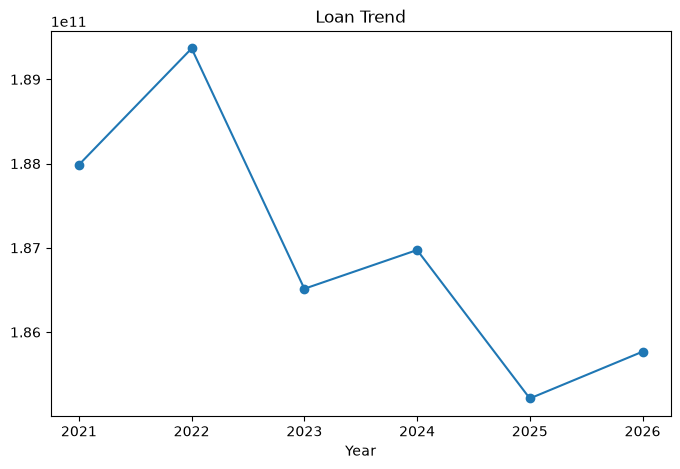

In [84]:
loan['SanctionDate']=pd.to_datetime(
loan['SanctionDate']
)

loan['Year']=loan['SanctionDate'].dt.year

loan.groupby('Year')['SanctionedAmount']\
.sum()\
.plot(marker='o',figsize=(8,5))

plt.title("Loan Trend")
plt.show()

Credit Score vs Default Rate

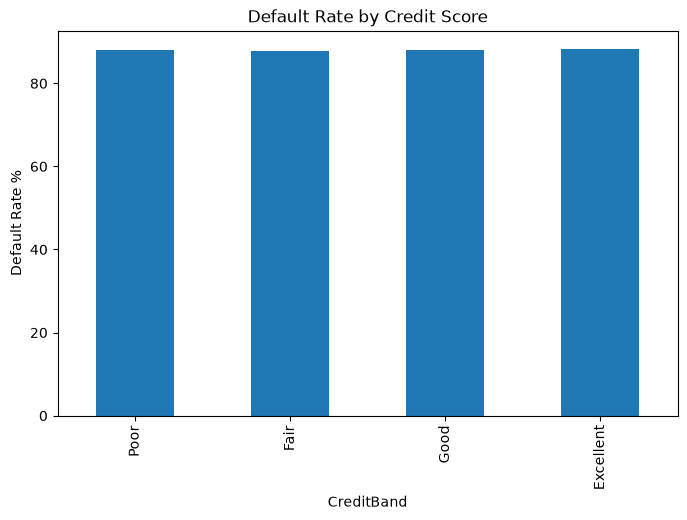

In [86]:
customer['CreditBand']=pd.cut(
    customer['CreditScore'],
    bins=[300,550,650,750,900],
    labels=['Poor','Fair','Good','Excellent']
)

loan_customer=loan.merge(
    customer[['CustomerID','CreditBand']],
    on='CustomerID'
)

default_rate=loan_customer.groupby('CreditBand')['LoanStatus']\
.apply(lambda x:(x!='Closed').mean()*100)

default_rate.plot(kind='bar',figsize=(8,5))

plt.ylabel("Default Rate %")
plt.title("Default Rate by Credit Score")
plt.show()

Income vs Loan Amount Ratio

In [87]:
loan_customer=loan.merge(
customer[['CustomerID','AnnualIncome']],
on='CustomerID'
)

loan_customer['LoanIncomeRatio']=(
loan_customer['SanctionedAmount']/
loan_customer['AnnualIncome']
)

loan_customer[['LoanIncomeRatio']].describe()

,LoanIncomeRatio
count,1.475790e+05
mean,3.770685e+01
std,3.397806e+03
min,2.587146e-04
25%,3.888189e-01
50%,1.431207e+00
75%,7.181554e+00
max,1.140774e+06


Top risky borrowers

In [88]:
loan_customer.nlargest(
20,
'LoanIncomeRatio'
)[['CustomerID','LoanIncomeRatio']]

,CustomerID,LoanIncomeRatio
33427,WB00084709,1.140774e+06
92514,WB00091996,3.767492e+05
64186,WB00091996,3.627258e+05
124297,WB00084709,3.100819e+05
142613,WB00085951,7.478789e+04
86900,WB00055848,7.258165e+04
24234,WB00055848,6.479254e+04
43223,WB00009714,5.610468e+04
3911,WB00082737,5.506677e+04
126888,WB00013837,4.177893e+04


Customers Taking Multiple Loans

In [89]:
multiple_loans=loan.groupby(
'CustomerID'
)['LoanID'].count()

multiple_loans.sort_values(
ascending=False
).head(20)

CustomerID
WB00041456    12
WB00054917    11
WB00087371    11
WB00030937    11
WB00059100    10
WB00018271    10
WB00061167     9
WB00011197     9
WB00001023     9
WB00091656     9
WB00045312     9
WB00050870     9
WB00010796     9
WB00099904     9
WB00069219     9
WB00069375     9
WB00038834     9
WB00037818     9
WB00033098     9
WB00077951     9
Name: LoanID, dtype: int64

Text(0, 0.5, 'Customers')

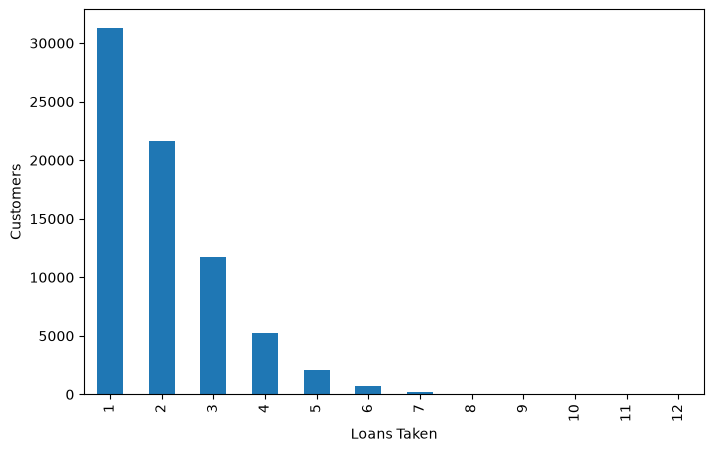

In [90]:
multiple_loans.value_counts().sort_index().plot(
kind='bar',
figsize=(8,5)
)

plt.xlabel("Loans Taken")
plt.ylabel("Customers")

Branch Risk Ranking

In [91]:
branch_risk=loan.merge(
branch[['BranchID','BranchName']],
on='BranchID'
)

risk=branch_risk.groupby(
'BranchName'
).agg(
Portfolio=('SanctionedAmount','sum'),
Outstanding=('OutstandingPrincipal','sum'),
Loans=('LoanID','count')
)

risk['Outstanding%']=(
risk['Outstanding']/
risk['Portfolio']*100
)

risk.sort_values(
'Outstanding%',
ascending=False
).head(15)

,Portfolio,Outstanding,Loans,Outstanding%
BranchName,,,,
New Delhi Branch 29,2064484254,1.493981e+09,275,72.365803
Chennai Branch 406,2993352217,2.117956e+09,390,70.755310
Mumbai Branch 384,2165409383,1.528418e+09,282,70.583315
Bengaluru Branch 30,1989642397,1.397369e+09,284,70.232192
Mumbai Branch 387,1868735739,1.310444e+09,260,70.124615
Chennai Branch 488,1991215510,1.393621e+09,284,69.988438
New Delhi Branch 21,2411184706,1.671874e+09,291,69.338287
New Delhi Branch 17,1844059183,1.274742e+09,240,69.126965
Hyderabad Branch 1,1847834104,1.274924e+09,272,68.995601


Which Loan Type Generates Highest Interest Income

Text(0.5, 1.0, 'Average Interest Rate')

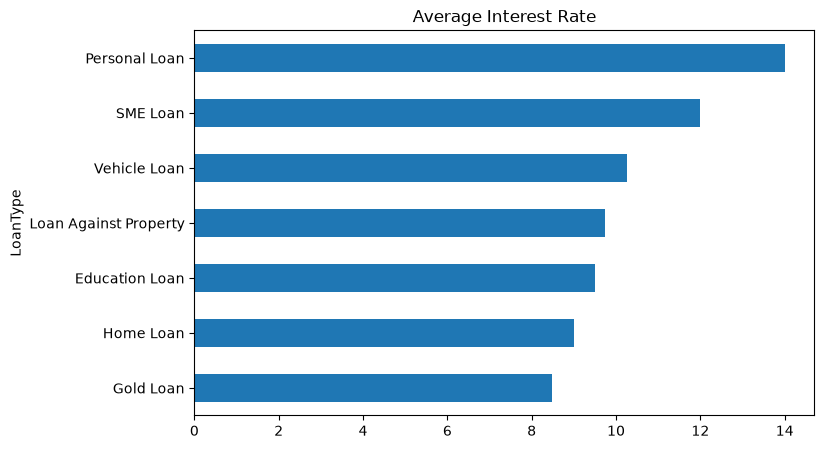

In [92]:
loan.groupby(
'LoanType'
)['InterestRate'].mean().sort_values().plot(
kind='barh',
figsize=(8,5)
)

plt.title("Average Interest Rate")

Customer Lifetime Value

In [93]:
repayment.groupby(
'CustomerID'
)['PrincipalPaid'].sum().sort_values(
ascending=False
).head(20)

CustomerID
WB00088724    41193786.79
WB00078683    37907005.62
WB00082214    31743071.11
WB00043719    29790593.20
WB00047551    28303063.96
WB00046362    28065240.40
WB00050763    27390288.35
WB00085610    27067400.71
WB00001036    26705023.57
WB00092814    26154596.65
WB00052947    25840610.58
WB00017111    25515606.54
WB00083821    25452588.36
WB00087863    25312737.00
WB00070449    25307549.92
WB00096209    25190630.73
WB00016431    25090059.32
WB00070501    24721730.36
WB00054582    24705742.00
WB00025826    24545699.55
Name: PrincipalPaid, dtype: float64

Payment Behaviour Score

In [94]:
payment_score=repayment.groupby(
'CustomerID'
).agg(

AvgDPD=('DaysPastDue','mean'),

LatePayments=('DaysPastDue',
lambda x:(x>0).sum()),

Payments=('RepaymentID','count')

)

payment_score['BehaviourScore']=100-(
payment_score['AvgDPD']*0.5+
payment_score['LatePayments']
)

payment_score.head()

,AvgDPD,LatePayments,Payments,BehaviourScore
CustomerID,,,,
WB00000002,0.125000,1,24,98.937500
WB00000003,0.000000,0,12,100.000000
WB00000004,13.483333,9,60,84.258333
WB00000005,11.375000,4,24,90.312500
WB00000008,1.666667,1,12,98.166667


Recovery Efficiency,Which frauds recover money successfully?

<Axes: ylabel='FraudType'>

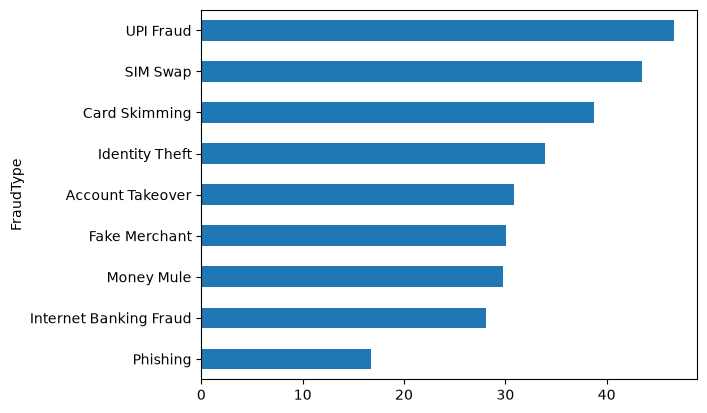

In [95]:
fraud['RecoveryRate']=(
fraud['RecoveredAmount']/
fraud['TransactionAmount']
)*100

fraud.groupby(
'FraudType'
)['RecoveryRate'].mean().sort_values().plot(
kind='barh'
)

High Value Customers by Branch

In [96]:
loan_branch=loan.merge(
branch[['BranchID','BranchName']],
on='BranchID'
)

top=loan_branch.groupby(
['BranchName','CustomerID']
)['SanctionedAmount'].sum()

top.groupby(level=0).nlargest(5)

BranchName          BranchName          CustomerID
Ahmedabad Branch 1  Ahmedabad Branch 1  WB00021431    118502928
                                        WB00080078     93149581
                                        WB00099211     71629954
                                        WB00030731     68168053
                                        WB00075839     65523827
                                                        ...    
Pune Branch 9       Pune Branch 9       WB00040680    102934300
                                        WB00017985     65018482
                                        WB00034663     63656429
                                        WB00026353     55453265
                                        WB00041757     55399990
Name: SanctionedAmount, Length: 2500, dtype: int64

Branch Productivity

In [97]:
branch_perf=loan.groupby(
'BranchID'
).agg(

Portfolio=('SanctionedAmount','sum'),

Loans=('LoanID','count')

)

branch_perf['AvgLoan']=(
branch_perf['Portfolio']/
branch_perf['Loans']
)

branch_perf.head()

,Portfolio,Loans,AvgLoan
BranchID,,,
BR0001,2219036771,286,7.758870e+06
BR0002,2024931161,264,7.670194e+06
BR0003,2469947779,324,7.623296e+06
BR0004,2429325285,328,7.406480e+06
BR0005,1888621419,300,6.295405e+06


Customer Segmentation

In [98]:
customer['IncomeBand']=pd.qcut(
customer['AnnualIncome'],
5,
labels=[
'Low',
'Lower Mid',
'Middle',
'Upper Mid',
'High'
]
)

customer.groupby(
'IncomeBand'
)['CreditScore'].mean()

IncomeBand
Low          599.57260
Lower Mid    599.68640
Middle       598.13905
Upper Mid    598.18095
High         601.27490
Name: CreditScore, dtype: float64

Collection Efficiency

<Axes: >

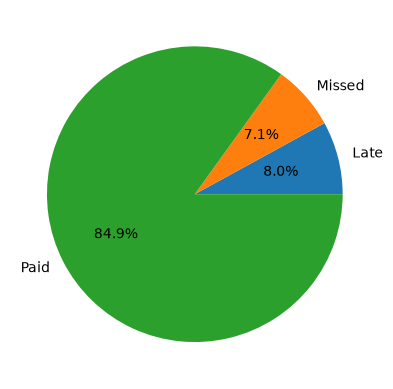

In [99]:
collection=repayment.groupby(
'PaymentStatus'
)['PrincipalPaid'].sum()

collection.plot(kind='pie',autopct='%1.1f%%')

Fraud Loss by Merchant

<Axes: xlabel='Merchant'>

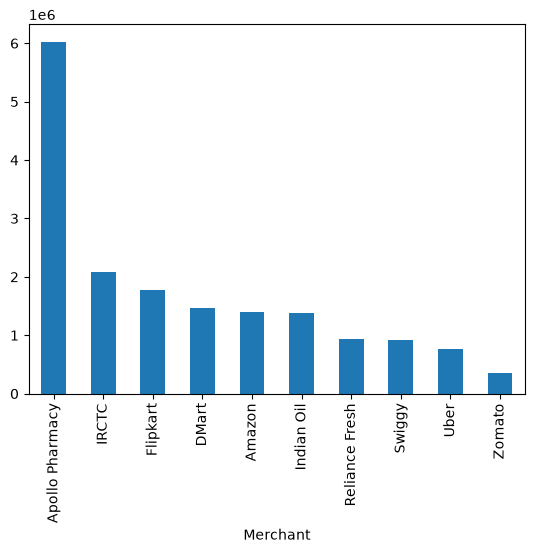

In [100]:
fraud.groupby(
'Merchant'
)['FinancialLoss'].sum()\
.sort_values(ascending=False)\
.head(15)\
.plot(kind='bar')

Fraud Hotspots by State

<Axes: xlabel='State'>

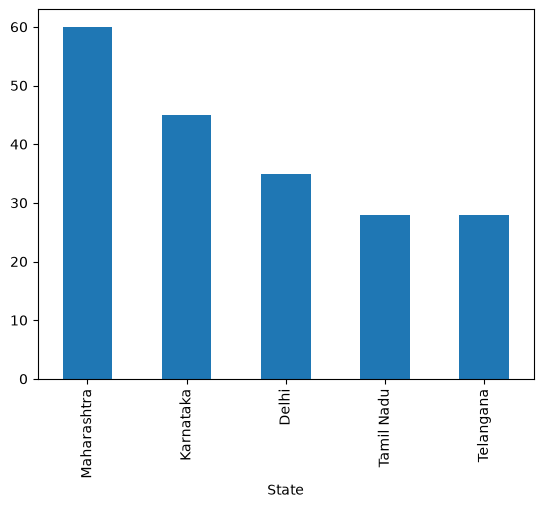

In [103]:
fraud.groupby(
branch['State']
)['FraudCaseID'].count().sort_values(
ascending=False
).plot(
kind='bar'
)

EMI Burden Analysis

In [104]:
loan_customer=loan.merge(
customer[['CustomerID','AnnualIncome']],
on='CustomerID'
)

loan_customer['EMIIncomeRatio']=(
loan_customer['EMI']*12/
loan_customer['AnnualIncome']
)

loan_customer[['EMIIncomeRatio']].describe()

,EMIIncomeRatio
count,147579.000000
mean,9.151735
std,929.887089
min,0.000112
25%,0.110416
50%,0.386032
75%,1.354914
max,292514.606667


Dormant Customers

In [105]:
active=transaction.groupby(
'CustomerID'
)['TransactionID'].count()

customer['Transactions']=customer['CustomerID'].map(active)

customer['Transactions']=customer['Transactions'].fillna(0)

customer.query("Transactions==0")

,CustomerID,FirstName,LastName,Gender,DateOfBirth,Age,PAN,Aadhaar,Mobile,Email,...,State,Pincode,CustomerSince,KYCStatus,PreferredChannel,BranchID,IsActive,CreditBand,IncomeBand,Transactions
1,WB00000002,Pooja,Patel,Male,2003-02-13,23,HQJJF5374W,966171396568,9720322983,pooja.patel2@mail.com,...,Tamil Nadu,600001,2024-03-09,Verified,Internet Banking,BR0134,1,Fair,Lower Mid,0.0
4,WB00000005,Neha,Nair,Male,1978-08-26,48,KCRJK1887V,660781151148,9088065007,neha.nair5@mail.com,...,Telangana,500001,2023-08-16,Verified,UPI,BR0167,1,Excellent,Upper Mid,0.0
8,WB00000009,Divya,Mehta,Male,1958-07-28,68,BMFXJ4728H,13892639591,9919214736,divya.mehta9@mail.com,...,Tamil Nadu,600001,2022-10-07,Verified,UPI,BR0148,0,Poor,High,0.0
9,WB00000010,Nikhil,Rao,Male,1981-11-11,45,QRDXN7691K,421496963502,9456442497,nikhil.rao10@mail.com,...,West Bengal,700001,2019-09-22,Verified,Internet Banking,BR0385,1,Good,High,0.0
11,WB00000012,Sneha,Das,Male,1968-05-15,58,CHHIO3267E,267045424956,9873037894,sneha.das12@mail.com,...,Delhi,110001,2025-04-09,Verified,Branch,BR0114,1,Excellent,Upper Mid,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99983,WB00099984,Priya,Das,Female,1961-04-20,65,PQJTM2150L,337926497435,9058303538,priya.das99984@mail.com,...,Tamil Nadu,600001,2010-07-11,Verified,UPI,BR0128,1,Excellent,High,0.0
99984,WB00099985,Nikhil,Reddy,Male,1954-03-28,72,TIGZW5756M,158767862670,9513867084,nikhil.reddy99985@mail.com,...,Telangana,500001,2016-01-15,Verified,Internet Banking,BR0480,1,Good,Low,0.0
99990,WB00099991,Karthik,Nair,Female,1971-02-15,55,OQSOT8814Y,754813348327,9902201026,karthik.nair99991@mail.com,...,Maharashtra,400001,2014-12-12,Verified,Internet Banking,BR0077,1,Poor,Low,0.0
99997,WB00099998,Amit,Kumar,Female,2003-11-27,23,WVLZV3532C,640196084439,9662562078,amit.kumar99998@mail.com,...,Telangana,500001,2024-08-09,Verified,Internet Banking,BR0332,0,Poor,Upper Mid,0.0


Branch Ranking Score

In [106]:
branch_rank=loan.merge(
branch[['BranchID','BranchName']],
on='BranchID'
)

summary=branch_rank.groupby(
'BranchName'
).agg(

Portfolio=('SanctionedAmount','sum'),

Loans=('LoanID','count'),

Outstanding=('OutstandingPrincipal','sum')

)

summary['Score']=(
summary['Portfolio'].rank(pct=True)*0.5+
summary['Loans'].rank(pct=True)*0.3-
summary['Outstanding'].rank(pct=True)*0.2
)

summary.sort_values(
'Score',
ascending=False
).head(20)

,Portfolio,Loans,Outstanding,Score
BranchName,,,,
Bengaluru Branch 462,2559346527,325,1.370829e+09,0.6067
Bengaluru Branch 349,3167113960,384,1.807398e+09,0.6027
Bengaluru Branch 20,3020938839,384,1.858016e+09,0.5977
Ahmedabad Branch 309,3052604426,383,1.872099e+09,0.5974
Kolkata Branch 362,2746696148,349,1.590315e+09,0.5973
New Delhi Branch 279,3153036600,379,2.120326e+09,0.5966
Chennai Branch 406,2993352217,390,2.117956e+09,0.5954
Mumbai Branch 490,2872523171,368,1.798812e+09,0.5914
Ahmedabad Branch 402,2705006007,359,1.654846e+09,0.5890


Early Warning List

In [107]:
loan_customer = loan.merge(
    customer[['CustomerID','CreditScore','AnnualIncome']],
    on='CustomerID'
)

latest_dpd = repayment.groupby('CustomerID')['DaysPastDue'].max().reset_index()

loan_customer = loan_customer.merge(
    latest_dpd,
    on='CustomerID',
    how='left'
)

loan_customer['EMIIncomeRatio'] = (
    loan_customer['EMI'] * 12 /
    loan_customer['AnnualIncome']
)

loan_customer['RiskScore'] = (
    (700 - loan_customer['CreditScore']) * 0.35 +
    loan_customer['DaysPastDue'].fillna(0) * 2 +
    loan_customer['EMIIncomeRatio'] * 100 * 0.25
)

early_warning = loan_customer.sort_values(
    'RiskScore',
    ascending=False
)

early_warning[['CustomerID','CreditScore','DaysPastDue','EMIIncomeRatio','RiskScore']].head(20)

,CustomerID,CreditScore,DaysPastDue,EMIIncomeRatio,RiskScore
33427,WB00084709,428,70,292514.606667,7.313100e+06
92514,WB00091996,336,14,172695.032308,4.317531e+06
124297,WB00084709,428,70,74074.853333,1.852107e+06
64186,WB00091996,336,14,69156.840000,1.729076e+06
86900,WB00055848,631,80,24160.763548,6.042032e+05
24234,WB00055848,631,80,19456.854194,4.866055e+05
142613,WB00085951,849,126,13683.505263,3.422875e+05
126888,WB00013837,865,174,10248.857882,2.565117e+05
3911,WB00082737,899,164,8630.401555,2.160184e+05
20842,WB00025358,583,176,8431.543385,2.111815e+05
